In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv('/content/train.csv')

In [5]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values.sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [8]:
columns_to_drop = [
    'PoolQC',
    'MiscFeature',
    'Alley',
    'Fence'
]

df = df.drop(columns=columns_to_drop)
print(df.shape)

(1460, 77)


In [9]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values.sort_values(ascending=False)

,0
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageYrBlt,81
GarageFinish,81
GarageType,81
GarageQual,81
GarageCond,81
BsmtExposure,38
BsmtFinType2,38


In [10]:
basement_cols = [
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2'
]

df[basement_cols] = df[basement_cols].fillna('None')

In [11]:
garage_cols = [
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond'
]

df[garage_cols] = df[garage_cols].fillna('None')

In [12]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

In [13]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values.sort_values(ascending=False)

,0
MasVnrType,872
FireplaceQu,690
LotFrontage,259
MasVnrArea,8
Electrical,1


In [14]:
df['MasVnrType'] = df['MasVnrType'].fillna('None')
df['FireplaceQu'] = df['FireplaceQu'].fillna('None')

In [15]:
df['LotFrontage'].describe()

,LotFrontage
count,1201.000000
mean,70.049958
std,24.284752
min,21.000000
25%,59.000000
50%,69.000000
75%,80.000000
max,313.000000


In [16]:
df['LotFrontage'] = df['LotFrontage'].fillna(
    df['LotFrontage'].median()
)

In [17]:
df['MasVnrArea'].describe()

,MasVnrArea
count,1452.000000
mean,103.685262
std,181.066207
min,0.000000
25%,0.000000
50%,0.000000
75%,166.000000
max,1600.000000


In [18]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(
    df['MasVnrArea'].median()
)

In [19]:
df['Electrical'] = df['Electrical'].fillna(
    df['Electrical'].mode()[0]
)

In [20]:
df.isnull().sum().sum()

np.int64(0)

**EDA**

In [21]:
df['SalePrice'].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


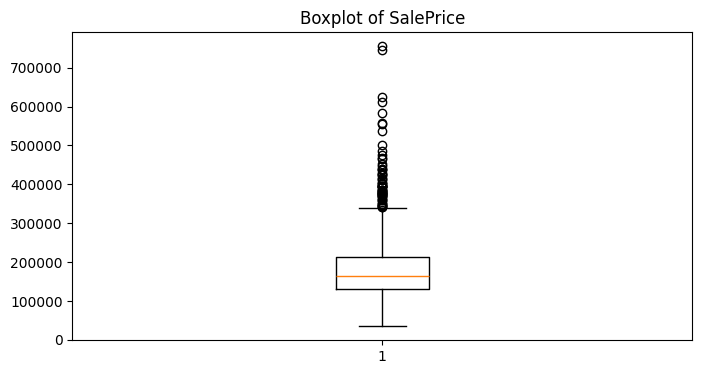

In [22]:
plt.figure(figsize=(8,4))
plt.boxplot(df['SalePrice'])
plt.title('Boxplot of SalePrice')
plt.show()

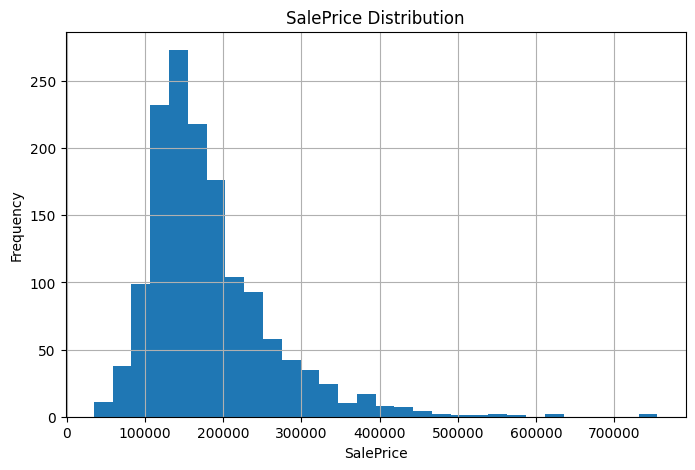

In [23]:
plt.figure(figsize=(8,5))
df['SalePrice'].hist(bins=30)

plt.title('SalePrice Distribution')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')

plt.show()

In [24]:
df['SalePrice'].skew()

np.float64(1.8828757597682129)

In [25]:
log_saleprice = np.log(df['SalePrice'])

print("Original Skewness:", df['SalePrice'].skew())
print("Log Skewness:", log_saleprice.skew())

Original Skewness: 1.8828757597682129
Log Skewness: 0.12133506220520406


**Correlation Analysis**

In [26]:
correlation = df.corr(numeric_only=True)
correlation['SalePrice'].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


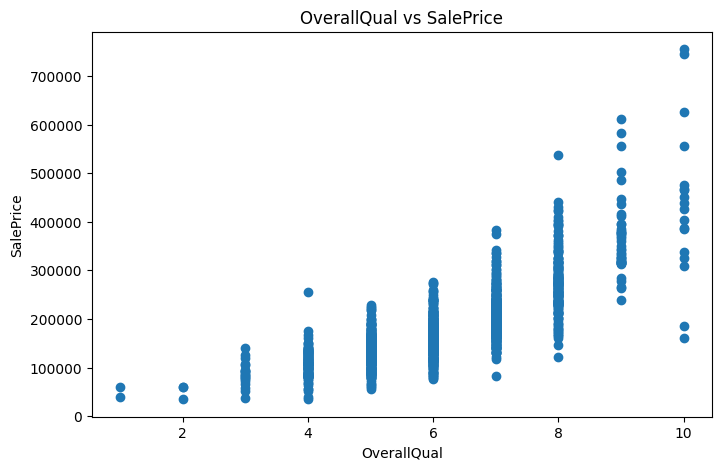

In [27]:
plt.figure(figsize=(8,5))
plt.scatter(df['OverallQual'], df['SalePrice'])

plt.xlabel('OverallQual')
plt.ylabel('SalePrice')
plt.title('OverallQual vs SalePrice')

plt.show()

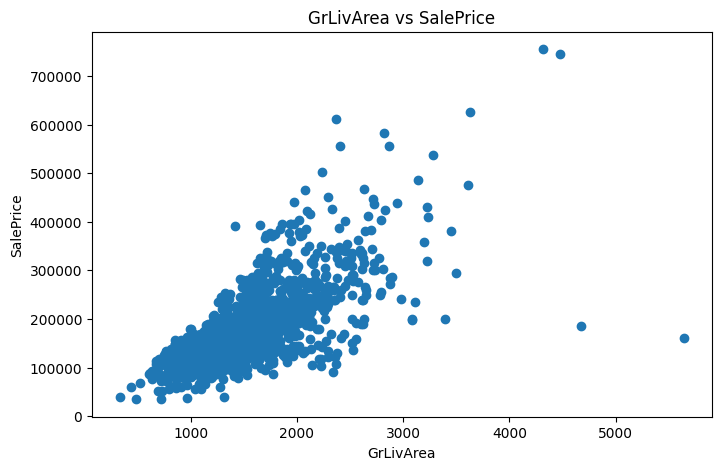

In [28]:
plt.figure(figsize=(8,5))
plt.scatter(df['GrLivArea'], df['SalePrice'])

plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.title('GrLivArea vs SalePrice')

plt.show()

In [29]:
df[df['GrLivArea'] > 4000][['GrLivArea', 'SalePrice']]

,GrLivArea,SalePrice
523,4676,184750
691,4316,755000
1182,4476,745000
1298,5642,160000


In [30]:
df = df.drop(
    df[
        (df['GrLivArea'] > 4000) &
        (df['SalePrice'] < 300000)
    ].index
)

print(df.shape)

(1458, 77)


In [31]:
categorical_cols = df.select_dtypes(include='object').columns

numerical_cols = df.select_dtypes(exclude='object').columns

print("Categorical Columns:", len(categorical_cols))
print("Numerical Columns:", len(numerical_cols))

Categorical Columns: 39
Numerical Columns: 38


In [32]:
print(categorical_cols.tolist())

['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


**Encoding**

In [33]:
ordinal_candidates = [
    'ExterQual',
    'ExterCond',
    'BsmtQual',
    'BsmtCond',
    'HeatingQC',
    'KitchenQual',
    'FireplaceQu',
    'GarageQual',
    'GarageCond'
]

for col in ordinal_candidates:
    print(f"\n{col}")
    print(df[col].unique())


ExterQual
['Gd' 'TA' 'Ex' 'Fa']

ExterCond
['TA' 'Gd' 'Fa' 'Po' 'Ex']

BsmtQual
['Gd' 'TA' 'Ex' 'None' 'Fa']

BsmtCond
['TA' 'Gd' 'None' 'Fa' 'Po']

HeatingQC
['Ex' 'Gd' 'TA' 'Fa' 'Po']

KitchenQual
['Gd' 'TA' 'Ex' 'Fa']

FireplaceQu
['None' 'TA' 'Gd' 'Fa' 'Ex' 'Po']

GarageQual
['TA' 'Fa' 'Gd' 'None' 'Ex' 'Po']

GarageCond
['TA' 'Fa' 'None' 'Gd' 'Po' 'Ex']


In [34]:
quality_mapping = {
    'None': 0,
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
}

In [35]:
ordinal_cols = [
    'ExterQual',
    'ExterCond',
    'BsmtQual',
    'BsmtCond',
    'HeatingQC',
    'KitchenQual',
    'FireplaceQu',
    'GarageQual',
    'GarageCond'
]

for col in ordinal_cols:
    df[col] = df[col].map(quality_mapping)

In [36]:
df[ordinal_cols].head()

,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,KitchenQual,FireplaceQu,GarageQual,GarageCond
0,4,3,4,3,5,4,0,3,3
1,3,3,4,3,5,3,3,3,3
2,4,3,4,3,5,4,3,3,3
3,3,3,3,4,4,4,4,3,3
4,4,3,4,3,5,4,3,3,3


In [37]:
remaining_categorical = df.select_dtypes(include='object').columns

print(len(remaining_categorical))
print(remaining_categorical.tolist())

30
['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'SaleType', 'SaleCondition']


In [38]:
df_encoded = pd.get_dummies(
    df,
    columns=remaining_categorical,
    drop_first=True
)

print(df_encoded.shape)

(1458, 219)


In [39]:
X = df_encoded.drop('SalePrice', axis=1)
y = np.log(df_encoded['SalePrice'])

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [41]:
# Train model
lr = LinearRegression()

lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.09081378327063254
RMSE: 0.12950381204576134
R²  : 0.9005138803806899


In [42]:
train_score = lr.score(X_train, y_train)
test_score = lr.score(X_test, y_test)

print("Train R²:", train_score)
print("Test R² :", test_score)

Train R²: 0.9483734725007265
Test R² : 0.9005138803806899


In [43]:
rf = RandomForestRegressor(n_estimators=100,random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest R²:", rf_r2)

Random Forest R²: 0.8760411595117721


**GradientBoost**

In [44]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    random_state=42
)

gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

gbr_r2 = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting R²:", gbr_r2)

Gradient Boosting R²: 0.9074084588360157


In [45]:
mae = mean_absolute_error(y_test, y_pred_gbr)

rmse = mean_squared_error(y_test, y_pred_gbr) ** 0.5

r2 = r2_score(y_test, y_pred_gbr)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.08830974241532491
RMSE: 0.1249358175044852
R²  : 0.9074084588360157


In [46]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'R2 Score': [
        0.9005138803806899,
        0.8760411595117721,
        0.9074084588360157
    ]
})

results.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,R2 Score
2,Gradient Boosting,0.907408
0,Linear Regression,0.900514
1,Random Forest,0.876041


In [47]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    gbr,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(cv_scores)
print("Average R²:", cv_scores.mean())

[0.90751192 0.90713043 0.89096574 0.90602115 0.90296664]
Average R²: 0.9029191765730132


In [48]:
import joblib
joblib.dump(gbr, 'house_price_model.pkl')

['house_price_model.pkl']